In [11]:
import os
import re
import sys
import json
import itertools
from pathlib import Path
import pandas as pd
from collections import defaultdict
import gurobipy as gp

from module import (
    route_prefix,
    travel_time_only,
    build_sched,
    od_distance_on_planned,
    planned_eids_of,
    get_arrival,
    build_arc_list_window,
    build_model_window,
    node_cap,
    merge_orders,
    build_canonical_station_order,
    sched_arr,
    sched_dep,
    plot_train_paths,
    h_get,
    plot_all_lines_global,
    plot_selected_lines,
    build_line_yorder,
    plot_lines_dynamic_y,
)

## Load data

In [12]:
import sys
import json
from pathlib import Path
from inputs import get_input_files

# Horizon and capacities
T          = 10
max_wait   = 4
CAPACITY_EDGE = 3
CAPACITY_NODE = 10

# Incident window and modelling constants
failed_edges =  {"e2"}  # set() or {"e91", "e91r","e101", "e101r"}
FAIL_T   = 0
T_clear  = 6
DWELL_MIN = 1
BIG_M     = 10**6

# REGION / DAY Settings
REGION = "toynet"          # "kor", "uk", "uk_real", "toynet"
DAY    = "MON"              # "MON", "TUE", "WED", "THU", "FRI", "SAT", "SUN" (only for uk_real)
MODULE_DIR = Path.cwd().resolve()
sys.path.insert(0, str(MODULE_DIR))

if REGION == "uk_real":
    if DAY is None:
        raise ValueError("If REGION is 'uk_real', DAY must be set to one of 'MON'...'SUN'.")
    fp = get_input_files("uk_real", DAY)
else:
    fp = get_input_files(REGION)

edges_raw    = json.loads(fp["edges"].read_text(encoding="utf-8"))
routes_nodes = json.loads(fp["route"].read_text(encoding="utf-8"))
dep_time_raw = json.loads(fp["dept"].read_text(encoding="utf-8"))
dem_raw      = json.loads(fp["demand"].read_text(encoding="utf-8"))
nodes_raw    = json.loads(fp["nodes"].read_text(encoding="utf-8"))

cap_node_path = fp.get("cap_node", None)
if cap_node_path is not None and cap_node_path.exists():
    cap_node_raw = json.loads(cap_node_path.read_text(encoding="utf-8"))
    CAPACITY_NODE = {str(k): int(v) for k, v in cap_node_raw.items()}
else:
    print("No CAPACITY_NODE file, using scalar CAPACITY_NODE =", CAPACITY_NODE)

dep_time = {tr: int(t) for tr, t in dep_time_raw.items()}

edges = {
    eid: (edata["from"], edata["to"], int(edata["tau"]))  
    for eid, edata in edges_raw.items()
}

demand = {
    tr: [(o, d, float(q)) for o, d, q in lst]
    for tr, lst in dem_raw.items()
}

node_xy = {
    nid: (float(v["x"]), float(v["y"]))
    for nid, v in nodes_raw.items()
}

trains = list(routes_nodes)
SINK   = "SINK"

nodes = {n for _, (s, d, _) in edges.items() for n in (s, d)}
nodes.add(SINK)

## Settings

In [13]:
import module as md

md.T            = T
md.FAIL_T       = FAIL_T
md.T_clear      = T_clear
md.DWELL_MIN    = DWELL_MIN
md.BIG_M        = BIG_M
md.CAPACITY_NODE = CAPACITY_NODE
md.SINK         = SINK
md.trains       = trains
md.routes_nodes = routes_nodes
md.dep_time     = dep_time
md.demand       = demand
md.nodes        = nodes
md.failed_edges = failed_edges
md.edges        = edges

In [14]:
sched = build_sched(routes_nodes, edges, dep_time, DWELL_MIN)
node_pos = {tr: {n: i for i, n in enumerate(path)} for tr, path in routes_nodes.items()}
edge_tau = {(s, d): tau for _, (s, d, tau) in edges.items()}

md.routes_nodes = routes_nodes
md.node_pos     = node_pos
md.edge_tau     = edge_tau

d_rd, qd_rd = {}, {}
for tr in trains:
    for (o, d, q) in demand[tr]:
        dd = od_distance_on_planned(tr, o, d)
        d_rd[(tr, o, d)]  = dd
        qd_rd[(tr, o, d)] = q * dd

md.sched = sched
md.qd_rd = qd_rd


In [15]:
# Group trains by route base
by_route = defaultdict(list)
for tr in trains:
    by_route[route_prefix(tr)].append(tr)


# Representative runtime per route base
route_runtime = {}
for rname, tr_list in by_route.items():
    reps = [tr for tr in tr_list if re.fullmatch(re.escape(rname) + r'\d+_1', tr)]
    if not reps:
        reps = [tr for tr in tr_list if tr.endswith('_1')]
    if not reps:
        reps = [sorted(tr_list)[0]]
    rep = reps[0]
    route_runtime[rname] = travel_time_only(routes_nodes[rep], edges)


# Time limit per train
PADDING_BASE = 6
T_limit = {}
for tr in trains:
    L = len(routes_nodes[tr]) - 1
    dwell_need = max(0, L-1) * DWELL_MIN
    base_run = route_runtime[route_prefix(tr)]
    T_limit[tr] = min(T, dep_time[tr] + base_run + dwell_need + PADDING_BASE)


# Map (u,v) to eid
uv2eid, dup_keys = {}, set()

for eid, (s, d, _) in edges.items():
    key = (s, d)
    if key in uv2eid and uv2eid[key] != eid:
        dup_keys.add(key)
    else:
        uv2eid[key] = eid
if dup_keys:
    print(f"[warn] duplicated (u,v) keys exist: {sorted(list(dup_keys))[:5]} ...")

md.uv2eid = uv2eid


# Planned eids
planned_eids = {tr: planned_eids_of(tr) for tr in trains}
blocked      = {tr: int(any(e in failed_edges for e in planned_eids[tr])) for tr in trains}
T_aff        = [tr for tr in trains if blocked[tr] == 1]
T_ok         = [tr for tr in trains if blocked[tr] == 0]


# Allowable termination nodes after incident position
allow_stop, reach = {}, {}
for tr in trains:
    path  = routes_nodes[tr]
    eids  = planned_eids[tr]
    L     = len(path) - 1
    last  = path[-1]
    t_arrival_last = get_arrival(tr, last, default=10**9)
    reach[tr] = int(t_arrival_last <= T_limit[tr])

    first_fail = next((idx for idx, e in enumerate(eids) if e in failed_edges), None)
    for i in range(1, L + 1):
        n = path[i]
        if i == L:
            allow = 1
        elif reach[tr] == 0:
            allow = 1
        else:
            allow = 1 if (first_fail is not None and i >= (first_fail + 1)) else 0
        allow_stop[(tr, n)] = int(allow)

In [16]:
CROSS = {}
for tr in trains:
    path = routes_nodes[tr]
    t = dep_time[tr]
    for u, v in zip(path[:-1], path[1:]):
        eid = uv2eid[(u, v)]
        tau = edges[eid][2]
        t0, t1 = t, t + tau
        if t0 < FAIL_T <= t1:
            CROSS[tr] = (u, v, eid, t0, t1)
            break
        t = t1
        if v != path[-1]:
            t += DWELL_MIN

## Rail scheduling
Dynamic optimization model

In [17]:
t_win_start = 0
t_win_end   = T

print(f"\n==== Window [{t_win_start}, {t_win_end}) ====")

window_ctx = build_arc_list_window(
    t_start=t_win_start, t_end=t_win_end,
    failed_edges=failed_edges, T_clear=T_clear,
    max_wait=max_wait, nodes=nodes, edges=edges,
    CROSS=CROSS
)

base, xvar, t_arr_var, delta_var, hvar, zvar, svar = build_model_window(
    window_ctx, t_win_start, t_win_end,
    planned_eids, routes_nodes,
    T_aff, T_ok, allow_stop, T_limit)

# edge capacity per time
constr_names = {}
for (eid, tt), idxs in window_ctx["cap_map"].items():
    real_idxs = [k for k in idxs if k >= 0]
    enabled_keys = [(k, ti) for k in real_idxs for ti in range(len(trains)) if (k, ti) in xvar]
    if not enabled_keys:
        continue
    expr = gp.quicksum(xvar[k, ti] for (k, ti) in enabled_keys)
    ghost = sum(1 for i in idxs if i < 0)
    rhs = max(0, CAPACITY_EDGE - ghost)
    base.addConstr(expr <= rhs, name=f"edgecap_{eid}_{tt}")
    constr_names[(eid, tt)] = f"edgecap_{eid}_{tt}"

# node capacity via wait arcs occupancy
node_dep_map = defaultdict(list)
for k, (fr, to, eid, _, t0, t1) in enumerate(window_ctx["arc_list"]):
    if str(eid).startswith(("w_", "dummy_")):
        continue
    n_fr, _ = fr.split("^")
    dep_t = t0  
    if t_win_start <= dep_t < t_win_end:
        node_dep_map[(n_fr, dep_t)].append(k)

for (n, tt), idxs in node_dep_map.items():
    enabled = [(k, ti) for k in idxs for ti in range(len(trains)) if (k, ti) in xvar]
    if not enabled:
        continue
    dep_trains = gp.quicksum(xvar[k, ti] for (k, ti) in enabled)
    base.addConstr(dep_trains <= node_cap(n), name=f"nodecap_departure_{n}_{tt}")

base.optimize()

if base.Status == gp.GRB.OPTIMAL:
    print(f"[OBJ] optimal objective = {base.ObjVal}")
elif base.Status in (gp.GRB.TIME_LIMIT, gp.GRB.INTERRUPTED):
    print(f"[OBJ] incumbent (best found) = {base.ObjVal}")
    print(f"[BND] best bound = {base.ObjBound}")
    print(f"[GAP] MIP gap = {base.MIPGap:.4%}")
elif base.Status == gp.GRB.INFEASIBLE:
    print("Model infeasible.")
else:
    print(f"Status: {base.Status}")

if base.Status == gp.GRB.INFEASIBLE:
    base.computeIIS()
    for c in base.getConstrs():
        if c.IISConstr:
            print(f"[IIS] {c.ConstrName}")
    for v in base.getVars():
        if getattr(v, "IISLB", 0) or getattr(v, "IISUB", 0):
            print(f"[IIS-Var] {v.VarName}  LB:{v.IISLB}  UB:{v.IISUB}")
    base.write(f"iis_win{t_win_start}_{t_win_end}.ilp")
    raise RuntimeError("infeasible (IIS written)")
elif base.Status != gp.GRB.OPTIMAL:
    raise RuntimeError(f"non-optimal status: {base.Status}")

# Extract solution
x_val   = {key: round(var.X) for key, var in xvar.items()}
h_final = {tr: 1.0 for tr in trains}

sol_legs = {tr: [] for tr in trains}
seen_arc_keys = set()

for tr in trains:
    ti = trains.index(tr)
    if tr in T_aff:
        try:
            h_final[tr] = float(hvar[tr].X)
        except KeyError:
            pass
    for k, (fr, to, eid, tau, t0, t1) in enumerate(window_ctx["arc_list"]):
        if x_val.get((k, ti), 0) <= 0.5:
            continue
        if str(eid).startswith(("w_", "dummy")):
            continue
        u, _t0 = fr.split("^"); v, _t1 = to.split("^")
        _t0 = int(_t0); _t1 = int(_t1)
        if _t1 < 0 or _t0 > T:
            continue
        key = (tr, _t0, u, v, _t1, eid)
        if key not in seen_arc_keys:
            seen_arc_keys.add(key)
            sol_legs[tr].append((_t0, u, v, _t1, eid))

print("Complete: sol_legs length =", {tr: len(sol_legs[tr]) for tr in trains})
print("\n==== Optimization done ====")


==== Window [0, 10) ====
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.0 build v12.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 5 3600XT 6-Core Processor, instruction set [SSE2|AVX|AVX2]
Thread count: 6 physical cores, 12 logical processors, using up to 12 threads

Optimize a model with 638 rows, 846 columns and 2938 nonzeros
Model fingerprint: 0x88c22666
Model has 3 quadratic objective terms
Model has 9 SOS constraints
Variable types: 78 continuous, 768 integer (768 binary)
Coefficient statistics:
  Matrix range     [3e-01, 1e+06]
  Objective range  [1e+00, 8e+02]
  QObjective range [4e+02, 8e+02]
  Bounds range     [1e+00, 1e+01]
  RHS range        [1e+00, 2e+06]
Presolve removed 427 rows and 510 columns
Presolve time: 0.02s
Presolved: 214 rows, 339 columns, 1249 nonzeros
Variable types: 54 continuous, 285 integer (272 binary)
Found heuristic solution: objective 2678.7125000
Found heuristic solution: objective 2597.6000000

Root relaxation: objec

## Rail timetable

In [18]:
# Global canonical order (requires user function build_canonical_station_order)
all_route_ids = list(routes_nodes.keys())
try:
    global_order = build_canonical_station_order(all_route_ids, routes_nodes)
except NameError:
    global_order = []
if not global_order:
    cnt = Counter(n for seq in routes_nodes.values() for n in seq if n != SINK)
    global_order = [n for n, _ in cnt.most_common()]
station_map_global = {name: i+1 for i, name in enumerate(global_order)}


# Group by line
by_line = defaultdict(list)
for tr in trains:
    by_line[route_prefix(tr)].append(tr)


# dynamic y-order per line
visited_by_train = {}
for tr, legs in sol_legs.items():
    nodes_visited = set()
    for _, u, v, _, eid in legs:
        if isinstance(eid, str) and (eid.startswith("w_") or str(eid).startswith("dummy_")):
            continue
        nodes_visited.add(u); nodes_visited.add(v)
    if not nodes_visited and tr in routes_nodes:
        nodes_visited.add(routes_nodes[tr][0])
    visited_by_train[tr] = nodes_visited

visited_by_line = {}
for line, trs in by_line.items():
    uni = set()
    for tr in trs:
        uni |= visited_by_train.get(tr, set())
    if SINK in uni:
        uni.remove(SINK)
    visited_by_line[line] = uni


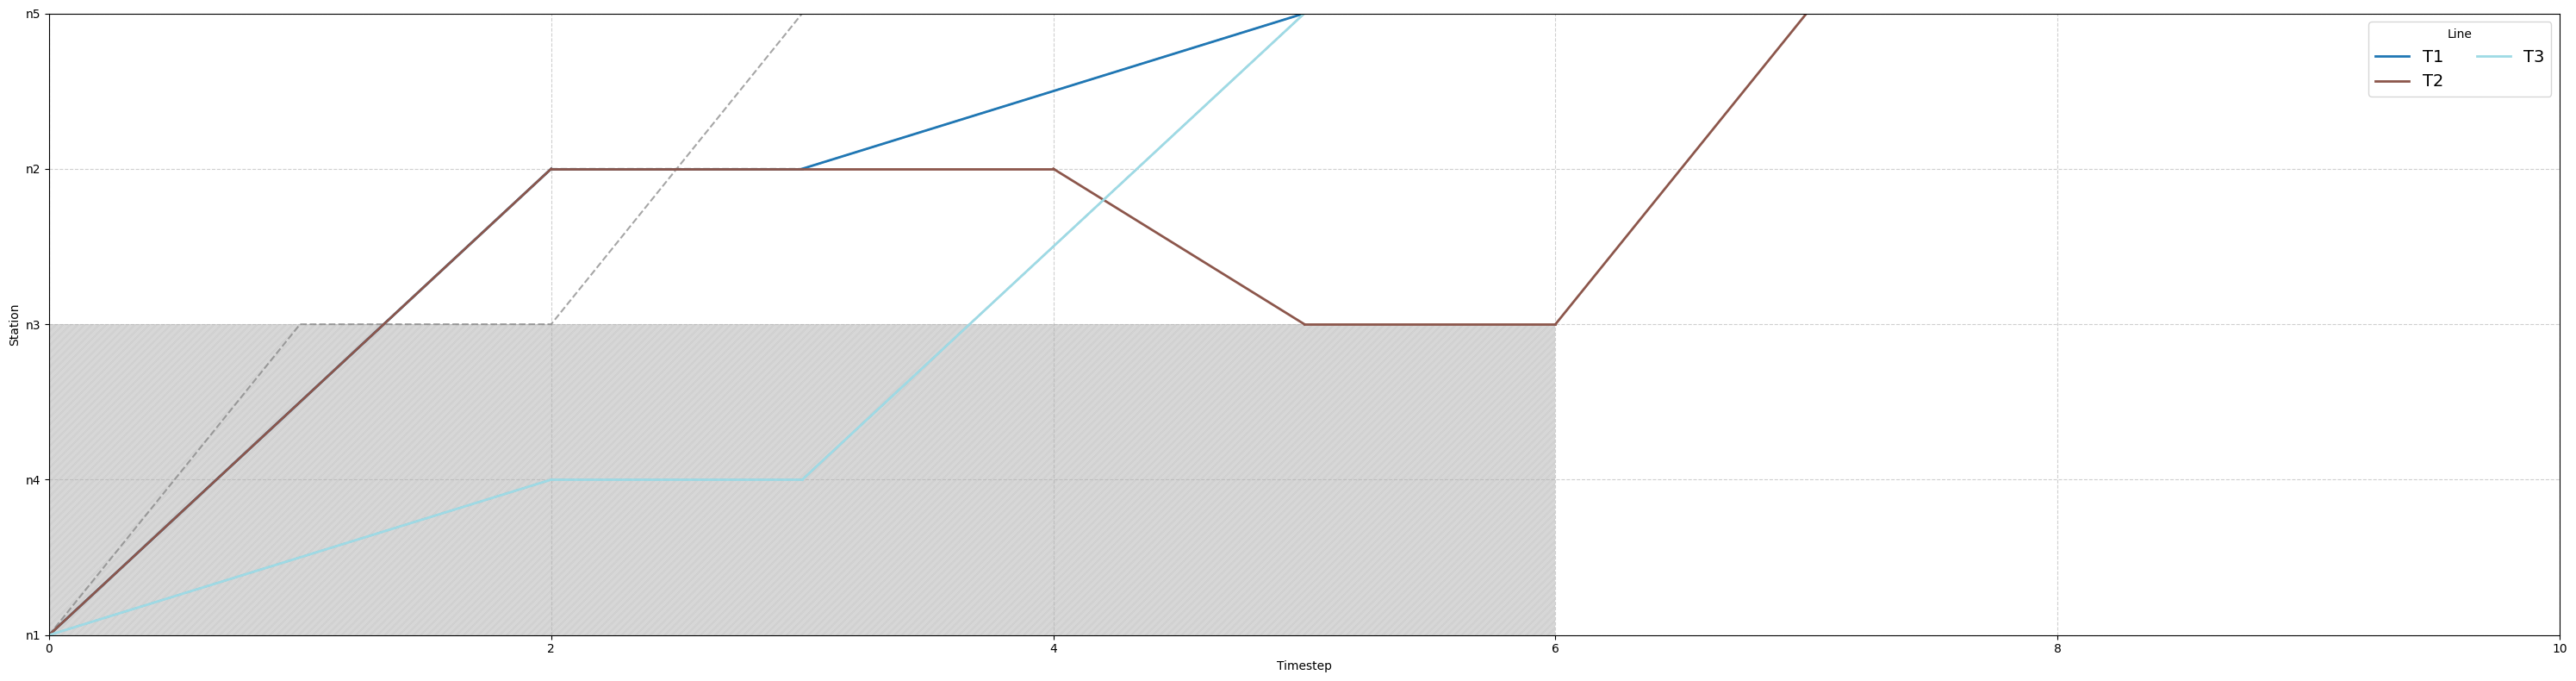

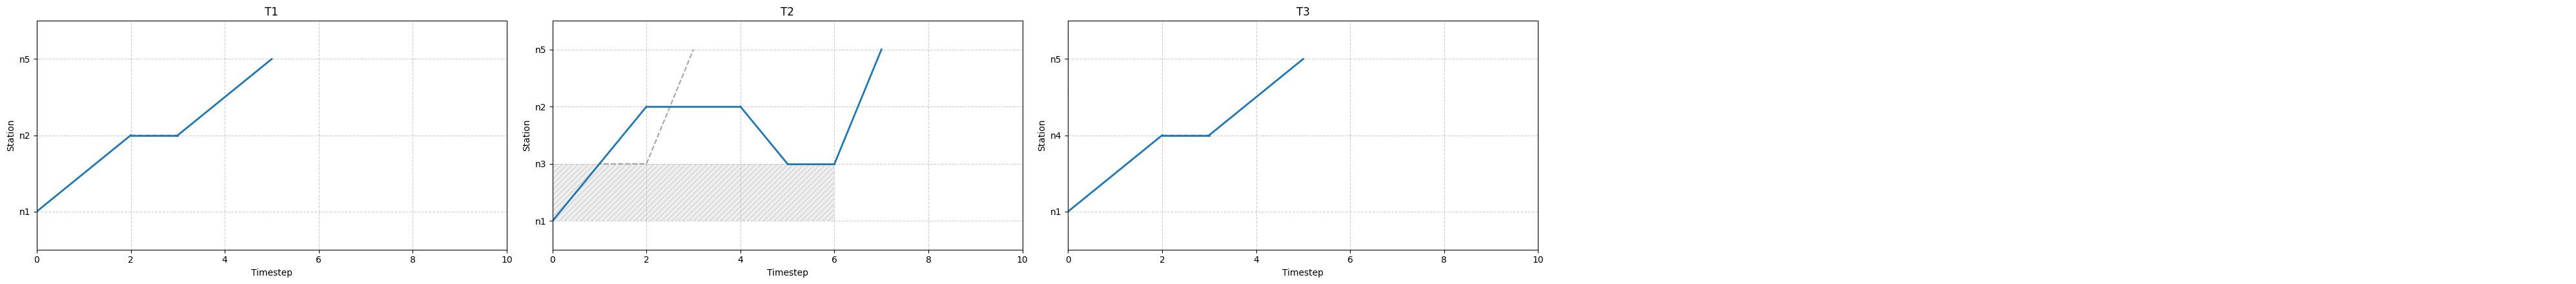

In [19]:
md.h_final = h_final
md.station_map_global = station_map_global
md.by_line = by_line
md.sol_legs = sol_legs
md.visited_by_train = visited_by_train
md.visited_by_line = visited_by_line
md.global_order = global_order

plot_all_lines_global(xmax=T)
plot_lines_dynamic_y(xmax=T)

In [20]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

pd.set_option('display.max_rows', None)

# --------------------------------
# 0. 보조 함수들
# --------------------------------
def h_get(tr):
    """T_aff는 h_final 값, 나머지는 1.0 취급."""
    return float(h_final.get(tr, 1.0))

def sched_arr_(tr, node):
    """계획 도착시간 반환, 없으면 None."""
    entry = sched.get(tr, {}).get(node)
    if isinstance(entry, dict) and ("arr" in entry):
        return entry["arr"]
    return None

def planned_path_and_eids(tr):
    """계획된 node_path와 edge_path(eid 시퀀스) 계산."""
    path = routes_nodes[tr]
    eids = []
    for u, v in zip(path[:-1], path[1:]):
        eid = next(e for e, (s, d, _) in edges.items() if s == u and d == v)
        eids.append(eid)
    return path, eids

def build_actual_legs(tr):
    """해당 기차의 실제 이동 leg 리스트 (sol_legs 기준)."""
    legs = sorted(sol_legs[tr], key=lambda v: v[0])  # (dep, frm, to, arr, eid)
    return legs

def path_nodes_from_legs(legs):
    """legs로부터 방문 노드 시퀀스 생성."""
    if not legs:
        return []
    nodes_seq = [legs[0][1]]  # 첫 frm
    for _, _, to, _, _ in legs:
        nodes_seq.append(to)
    return nodes_seq

def actual_arrival_map(legs):
    """노드별 실제 도착시간(min) 맵: node -> earliest arr."""
    amap = {}
    for _, frm, to, arr, _ in legs:
        if to not in amap or arr < amap[to]:
            amap[to] = arr
    return amap

# --------------------------------
# 1) 기차별 상태 정보 계산
#    (Truncated, Rerouted, TrainStatus)
# --------------------------------
stat_rows = []

for tr in trains:
    departed = (h_get(tr) >= 0.5) or (len(sol_legs[tr]) > 0)

    planned_path, planned_eids = planned_path_and_eids(tr)
    planned_terminal = planned_path[-1]
    planned_terminal_sched = sched_arr_(tr, planned_terminal)

    if not departed:
        stat_rows.append({
            "Train": tr,
            "Truncated": False,
            "Rerouted": False,
            "TrainStatus": "Cancelled",
        })
        continue

    # 실제 경로 정보
    legs    = build_actual_legs(tr)
    arr_map = actual_arrival_map(legs)
    actual_nodes = path_nodes_from_legs(legs)
    actual_eids  = [e for *_, e in legs]
    actual_terminal = actual_nodes[-1] if actual_nodes else None
    actual_arrival  = max(arr for *_, arr, _ in legs) if legs else None

    # 계획 경로에서 T 이내까지의 prefix 구간
    prefix_last_idx = 0
    for i, node in enumerate(planned_path):
        t_planned = sched_arr_(tr, node)
        if t_planned is not None and t_planned <= T:
            prefix_last_idx = i
    planned_prefix_nodes = planned_path[:prefix_last_idx+1]
    planned_prefix_eids  = planned_eids[:max(0, prefix_last_idx)]

    # horizon 안에서 도착했는지
    arrived_in_horizon = (
        actual_terminal == planned_terminal and
        (actual_arrival is not None) and
        (actual_arrival <= T)
    )

    # truncation 여부
    if (planned_terminal_sched is not None) and (planned_terminal_sched <= T):
        truncated = not arrived_in_horizon
    else:
        truncated = False

    # reroute 여부 (prefix 구간 비교)
    common = min(len(actual_eids), len(planned_prefix_eids))
    rerouted = (actual_eids[:common] != planned_prefix_eids[:common])

    # 지연 기반 status
    delay_min = None
    horizon_delay_min = None

    if (planned_terminal_sched is not None) and (planned_terminal_sched <= T) and arrived_in_horizon:
        delay_min = max(0, actual_arrival - planned_terminal_sched)

    if planned_prefix_nodes:
        last_plan_node = planned_prefix_nodes[-1]
        t_plan_last    = sched_arr_(tr, last_plan_node)
        t_act_last     = arr_map.get(last_plan_node, None)
        if (t_plan_last is not None) and (t_act_last is not None):
            horizon_delay_min = max(0, t_act_last - t_plan_last)

    if not departed:
        status = "Cancelled"
    elif truncated:
        status = "Truncated"
    elif rerouted:
        status = "Rerouted"
    elif ((planned_terminal_sched is not None and planned_terminal_sched <= T and delay_min and delay_min > 0)
          or (horizon_delay_min is not None and horizon_delay_min > 0)):
        status = "Delayed"
    else:
        if planned_terminal_sched is not None and planned_terminal_sched > T and not arrived_in_horizon:
            status = "On-time & in-progress"
        else:
            status = "On-time & complete"

    stat_rows.append({
        "Train": tr,
        "Truncated": truncated,
        "Rerouted": rerouted,
        "TrainStatus": status,
    })

df_stat = pd.DataFrame(stat_rows)

# dict 형태로 사용하기 쉽게 변환
truncated_map = dict(zip(df_stat["Train"], df_stat["Truncated"]))
rerouted_map  = dict(zip(df_stat["Train"], df_stat["Rerouted"]))
status_map    = dict(zip(df_stat["Train"], df_stat["TrainStatus"]))

# --------------------------------
# 2) 노드별 지연 맵 (To 노드 기준)
# --------------------------------
delay_at_node = {}  # key: (Train, node) -> delay at that node

for tr in trains:
    legs = build_actual_legs(tr)
    arr_map = actual_arrival_map(legs)
    for node, actual_arr in arr_map.items():
        sched_a = sched_arr_(tr, node)
        if sched_a is None:
            continue
        delay_at_node[(tr, node)] = max(0, actual_arr - sched_a)

# --------------------------------
# 3) Timetable + per leg 정보 붙이기
# --------------------------------
rows = []
for tr in trains:
    # 기차 상태 정보
    truncated_flag = truncated_map.get(tr, False)
    rerouted_flag  = rerouted_map.get(tr, False)
    status_str     = status_map.get(tr, None)

    # 출발 안 한 기차
    if h_get(tr) < 0.5 and len(sol_legs[tr]) == 0:
        rows.append([
            tr, '-', '-', '-', '-', 'Cancelled',
            None, truncated_flag, rerouted_flag, status_str
        ])
        continue

    # 실제 leg 순회
    legs = sorted(sol_legs[tr], key=lambda v: v[0])
    for dep, frm, to, arr, eid in legs:
        # 이 leg의 도착 노드에서의 delay
        delay_here = delay_at_node.get((tr, to), None)
        rows.append([
            tr, frm, dep, to, arr, eid,
            delay_here, truncated_flag, rerouted_flag, status_str
        ])

df_timetable = pd.DataFrame(rows, columns=[
    "Train", "From", "Dep", "To", "Arr", "Edge",
    "LegDelay", "Truncated", "Rerouted", "TrainStatus"
])

print("\n=== Timetable with leg delays and train status ===")
display(df_timetable)

# --------------------------------
# 4) 지도용 delay_df 생성 (node 단위)
#    train, node, delay 컬럼으로 요약
# --------------------------------
delay_rows = []
for (tr, node), dval in delay_at_node.items():
    delay_rows.append({
        "train": tr,
        "node": node,
        "delay": float(dval),
    })
delay_df = pd.DataFrame(delay_rows)

print("\n=== Node-level delay summary (for mapping) ===")
display(delay_df)

# --------------------------------
# 5) Leaflet HTML 생성 (rail_delay_only_leaflet.html)
#    delay_df 사용
# --------------------------------
df_map = delay_df.copy()
if not {"lon", "lat"}.issubset(df_map.columns):
    # node_xy: {node_id: (lon, lat)} 가 이미 main 코드에서 정의되어 있다고 가정
    df_map[["lon", "lat"]] = df_map["node"].map(
        lambda n: node_xy.get(n, (np.nan, np.nan))
    ).apply(pd.Series)

df_map = df_map.dropna(subset=["lon", "lat"])
if df_map.empty:
    raise RuntimeError("No rows with coordinates are available.")

# Spatial extent and center
lon_min, lon_max = df_map["lon"].min(), df_map["lon"].max()
lat_min, lat_max = df_map["lat"].min(), df_map["lat"].max()
span = max(lon_max - lon_min, lat_max - lat_min)
pad = 0.1 * span
center_lon = (lon_min + lon_max) / 2
center_lat = (lat_min + lat_max) / 2
bounds = [[lat_min - pad, lon_min - pad], [lat_max + pad, lon_max + pad]]

# Color palette (12 colors from prism)
cmap = plt.cm.get_cmap("prism")
palette = [
    f"rgba({int(r*255)},{int(g*255)},{int(b*255)},1.0)"
    for (r, g, b, a) in cmap(np.linspace(0, 1, 12))
]

def build_bins(series, anchors, eps=1e-6):
    vals = [series.min(), series.max()]
    edges = sorted({float(a) for a in anchors + vals if np.isfinite(a)})
    if len(edges) == 1:
        edges = [edges[0] - 0.5, edges[0] + 0.5]
    out = [edges[0]]
    for v in edges[1:]:
        if v <= out[-1]:
            v = out[-1] + eps
        out.append(v)
    return out

def make_bins(series, anchors):
    bins = build_bins(series, anchors)
    cut = pd.cut(series, bins=bins, include_lowest=True)
    labels = [str(cat) for cat in cut.cat.categories]
    cmap_local = {lab: palette[i % len(palette)] for i, lab in enumerate(labels)}
    return cut.astype(str), labels, cmap_local

def scale_size(series, min_px=6, max_px=24):
    if series.max() == series.min():
        return np.full_like(series, (min_px + max_px) / 2, dtype=float)
    n = (series - series.min()) / (series.max() - series.min())
    return min_px + n * (max_px - min_px)

# delay > 0 인 노드만 사용
sub = df_map[df_map["delay"] > 0].copy()
if sub.empty:
    print("No positive delay rows, map will not be very informative.")
bins, labels, cmap_local = make_bins(sub["delay"], anchors=[0, 0.01, 1, 3, 6])
sizes = scale_size(sub["delay"])

points = []
for (_, row), bin_lab, sz in zip(sub.iterrows(), bins, sizes):
    points.append({
        "lat": float(row["lat"]), "lon": float(row["lon"]),
        "train": row["train"], "node": row["node"],
        "val": float(row["delay"]), "bin": bin_lab,
        "color": cmap_local[bin_lab], "size": float(sz),
    })

summary = {
    "center": {"lat": center_lat, "lon": center_lon},
    "bounds": bounds,
    "points": points,
    "legend": [{"label": lab, "color": cmap_local[lab]} for lab in labels],
}
summary_json = json.dumps(summary)

html = f"""
<!doctype html><html><head>
<meta charset="utf-8"><title>Total delay map</title>
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<link rel="stylesheet" href="https://unpkg.com/leaflet@1.9.4/dist/leaflet.css" crossorigin="">
<style>
html, body, #map {{ height:100%; margin:0; }}
.panel {{
  background:white; padding:8px; border-radius:6px;
  box-shadow:0 2px 6px rgba(0,0,0,0.3);
  font-size:12px; line-height:1.35;
}}
.legend-color {{
  display:inline-block; width:12px; height:12px; margin-right:6px;
  vertical-align:middle; border:1px solid #333; border-radius:50%;
}}
</style></head><body><div id="map"></div>
<script src="https://unpkg.com/leaflet@1.9.4/dist/leaflet.js" crossorigin=""></script>
<script>
const summary = {summary_json};
const map = L.map('map');
L.tileLayer('https://tile.openstreetmap.org/{{z}}/{{x}}/{{y}}.png', {{
  maxZoom:18, attribution:'&copy; OpenStreetMap contributors'
}}).addTo(map);

// Fit initial view
try {{
  const b = summary.bounds;
  map.fitBounds([[b[0][0], b[0][1]], [b[1][0], b[1][1]]], {{padding:[10,10]}});
}} catch (e) {{
  map.setView([summary.center.lat, summary.center.lon], 8);
}}

// Single layer for total delay
const lg = L.layerGroup();
summary.points.forEach(p => {{
  const c = L.circleMarker([p.lat, p.lon], {{
    radius: p.size,
    color: '#000',
    weight: 0.5,
    fillColor: p.color,
    fillOpacity: 0.5
  }});
  c.bindPopup(`<div><b>Train</b>: ${'{'}p.train{'}'}<br/>
    <b>Node</b>: ${'{'}p.node{'}'}<br/>
    <b>Total delay</b>: ${'{'}p.val{'}'}</div>`);
  c.addTo(lg);
}});
lg.addTo(map);

// Legend panel
const ctl = L.control({{position:'topright'}});
ctl.onAdd = function() {{
  const div = L.DomUtil.create('div','panel');
  div.innerHTML = '<b>Total delay (bins)</b><br/>';
  summary.legend.forEach(item => {{
    const row = document.createElement('div');
    row.innerHTML = `<span class="legend-color" style="background:${'{'}item.color{'}'}"></span>${'{'}item.label{'}'}`;
    div.appendChild(row);
  }});
  L.DomEvent.disableClickPropagation(div);
  return div;
}};
ctl.addTo(map);
</script></body></html>
"""

html_path = Path("rail_delay_only_leaflet.html")
html_path.write_text(html, encoding="utf-8")
print("saved:", html_path.resolve())

excel_path = Path(f"opt_results_timetable_{DAY}.xlsx")

with pd.ExcelWriter(excel_path, engine="xlsxwriter") as writer:
    df_timetable.to_excel(writer, index=False, sheet_name="timetable")
    delay_df.to_excel(writer, index=False, sheet_name="node_delay")

print("saved excel:", excel_path.resolve())


=== Timetable with leg delays and train status ===


,Train,From,Dep,To,Arr,Edge,LegDelay,Truncated,Rerouted,TrainStatus
0,T1,n1,0,n2,2,e1,0.0,False,False,On-time & complete
1,T1,n2,3,n5,5,e6,0.0,False,False,On-time & complete
2,T2,n1,0,n2,2,e1,NaN,False,True,Rerouted
3,T2,n2,4,n3,5,e4,4.0,False,True,Rerouted
4,T2,n3,6,n5,7,e7,4.0,False,True,Rerouted
5,T3,n1,0,n4,2,e3,0.0,False,False,On-time & complete
6,T3,n4,3,n5,5,e8,0.0,False,False,On-time & complete



=== Node-level delay summary (for mapping) ===


,train,node,delay
0,T1,n2,0.0
1,T1,n5,0.0
2,T2,n3,4.0
3,T2,n5,4.0
4,T3,n4,0.0
5,T3,n5,0.0


saved: C:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\rail_delay_only_leaflet.html
saved excel: C:\Users\Minji Kang\Documents\GitHub\railnet_opt\03_rail_scheduling_dynamic_opt\opt_results_timetable_MON.xlsx


C:\Users\Minji Kang\AppData\Local\Temp\ipykernel_32060\1587467866.py:245: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("prism")
